## Расчёт размера выборки

In [19]:
import pandahouse
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import hashlib 
import swifter 
from scipy import stats 
from scipy.stats import norm, ttest_ind
from tqdm import tqdm
%matplotlib inline

In [2]:
rng = np.random.default_rng()

In [3]:
connection = {
    'host' : 'http://clickhouse.lab.karpov.courses:8123',
    'password' : 'dpo_python_2020',
    'user' : 'student',
    'database' : 'simulator_20260320'
}

### Оценка размера выборки с помощью калькулятора размера выборки

Для оценки размера выборки в калькуляторах используется формула:

$$n > \frac{\left[ \Phi^{-1} \left( 1-\alpha \right) + \Phi^{-1} \left( 1-\beta \right) \right]^2 (\sigma_X^2 + \sigma_Y^2)}{\varepsilon^2}$$

Здесь $\varepsilon$ - размер эффекта, $\alpha$ - вероятность ошибки первого рода, $\beta$ - вероятность ошибки 2 рода (0.1-0.2), $\sigma_X^2$ и $\sigma_Y^2$ − стандартные отклонения в контрольной и экспериментальной группах соответственно. 

Для использования формулы нужно: 
1) Зафиксировать размер эффекта
2) Вероятность ошибки 2 рода (beta) - вероятность не обнаружить эффект, когда он есть
3) Вероятность ошибки 1 рода (alpha) - вероятность ошибочно обнаружить эффект, если его нет
4) Стандартные отклонения в группах

In [7]:
#выгрузим распределение CTR на даты AA-теста
q = """
select 
   floor(ctr, 2) as ctr, count() as users
from (select toDate(time) as dt, 
    user_id,
    sum(action = 'like')/sum(action = 'view') as ctr
FROM {db}.feed_actions
where dt between '2026-02-20' and '2026-02-26'
group by dt, user_id
)
group by ctr
"""


ctr_distribution = pandahouse.read_clickhouse(q, connection=connection) #достанем распределение cTR за эту неделю

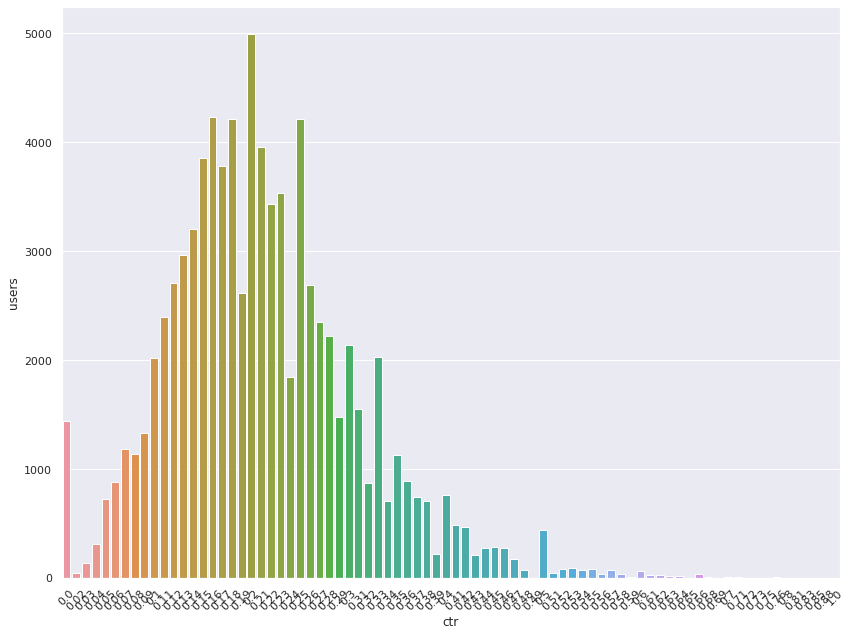

In [17]:
#визуализируем CTR
sns.set(rc={'figure.figsize':(12,9)})
ax=sns.barplot(data= ctr_distribution, x='ctr', y='users')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

In [18]:
#рассчитаем средний CTR
print((ctr_distribution.ctr*ctr_distribution.users).sum()/ctr_distribution.users.sum())

0.21222988451733416


CTR был 0.21. Допустим, мы хотим замечать увеличение CTR на 0.01 п.п- это будет размер эффекта

Вероятность ошибки 2 рода (beta) = 0.02
Вероятность ошибки 1 рода (alpha) = 0.05

In [19]:
#рассчитаем стандартное отклонение
q = """
select 
   stddevPop(ctr) as ctr_std
from (select toDate(time) as dt, 
    exp_group,
    user_id,
    sum(action = 'like')/sum(action = 'view') as ctr
from {db}.feed_actions
where dt between '2026-02-20' and '2026-02-26'
    and exp_group in (0,1,2,3,4)
group by dt, exp_group, user_id
)

"""

std = pandahouse.read_clickhouse(q, connection=connection).values[0][0]
std

0.0984458178473624

In [3]:
#Напишем функцию для оценки размера выборки
def compute_sample_size_abs(epsilon, std1, std2, alpha=0.05, beta=0.2):
    t_alpha = norm.ppf(1 - alpha / 2, loc=0, scale=1)
    t_beta = norm.ppf(1 - beta, loc=0, scale=1)
    z_scores_sum_squared = (t_alpha + t_beta) ** 2
    sample_size = int(
        np.ceil(
            z_scores_sum_squared * (std1 ** 2 + std2 ** 2) / (epsilon ** 2)
        )
    )
    return sample_size

In [20]:
#рассчитаем размер выборки по формуле
compute_sample_size_abs(0.01, std, std)

1522

### Оценка размера выборки методом Монте-Карло

Метод Монте-Карло — это способ оценивать результат через многократное случайное моделирование. Подбираем такой размер выборки, при котором мощность становится 80%, что означает, что мы обнаруживаем эффект в 80% случаев. Для этого:

1) Берём исторические данные или A/A-тест,
2) Искусственно вносим эффект,
3) Фиксируем количество тестов N и начальный размер выборки n
4) Сэмплируем n наблюдений из групп
5) Проводим между этими группами тестирование
6) Считаем, в каком проценте групп тест заметил эффект, и делаем вывод о размере выборки.
7) Если получаем процент меньший, чем выбранная мощность - 80% , то необходимо увеличить количество наблюдений, если получаем больший, то можно попробовать уменьшить количество наблюдений.

### Задача 1
К нам пришли наши коллеги из ML-отдела и рассказали, что планируют выкатывать новый алгоритм, рекомендующий нашим пользователям интересные посты. После обсуждений того, как он это делает, вы пришли к следующему пониманию: <br>

Алгоритм добавляет пользователям 1-2 просмотра<br>
Вероятность того, что он сработает, составляет 90%<br>
Если у пользователя меньше 50 просмотров, то алгоритм не сработает<br><br>
Вы предполагаете, что увеличение числа просмотров приведёт и к увеличению лайков на пользователя. Встаёт вопрос: сможем ли мы обнаружить различия в среднем количестве лайков на пользователя? Чтобы ответить на этот вопрос, давайте проведём симуляцию Монте-Карло!

Что мы будем делать:<br>

1) Построим на основе периода АА-теста распределения для генерации просмотров и CTR. Выгрузим данные запросами.<br>
2) На эксперимент нам выделили неделю. Мы планируем разбивать пользователей на две группы в соотношении 50/50. Посчитайте, сколько пользователей в таком случае придётся на одну группу. <br>
3) Эффект алгоритма на просмотры мы сымитируем следующим образом: group_B_views + ((1 + np.binomial(n=1, p=0.5, size=размер_выборки)) * np.binomial(n=1, p=0.9, size=размер_выборки) * (group_B_views >= 50)).
4) Количество симуляций задайте не меньше 20000. Если хотите ещё больше уверенности в своих результатах — можете увеличить их число.
5) Лайки мы будем сравнивать t-тестом с поправкой Уэлча на неравные дисперсии (equal_var=False). Уровень значимости по классике поставим 0.05.
6) В ответе укажите получившееся значение мощности в процентах до первого знака после точки. Например, если у вас получится мощность, равная 0.919, то в ответе укажите 91.9.

#### 1) Берём данные АА-теста из следующего диапазона: с '2026-02-20' по '2026-02-26'

In [9]:
#выгрузим просмотры на даты AA-теста
q = """
SELECT
    views, count() as users
FROM (select 
    user_id,
    sum(action = 'view') as views
FROM {db}.feed_actions
where toDate(time) between '2026-02-20' and '2026-02-26'
group by user_id
)
group by views
order by views
"""


views_distribution = pandahouse.read_clickhouse(q, connection=connection)
views_distribution

,views,users
0,1,4
1,2,1
2,3,4
3,4,5
4,5,18
...,...,...
296,324,1
297,326,1
298,355,1
299,364,1


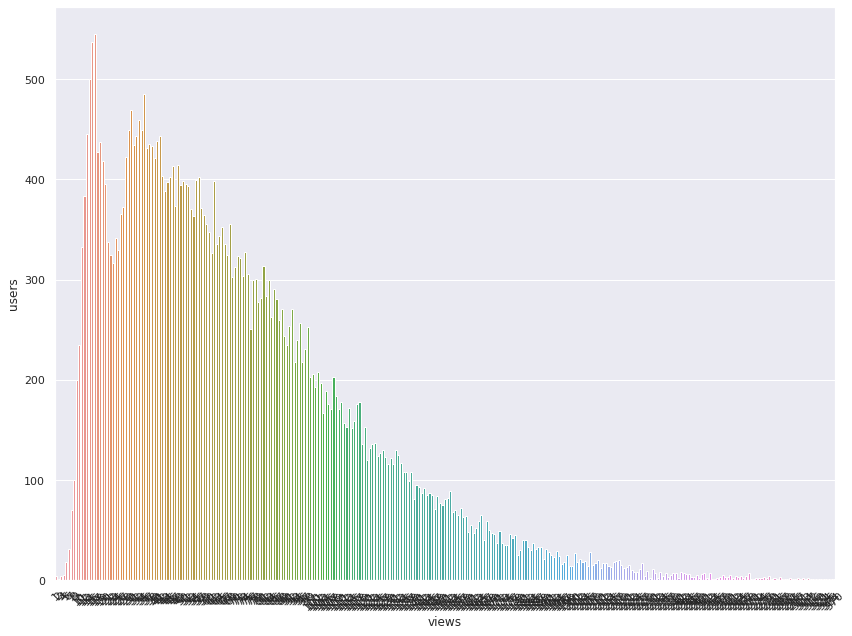

In [10]:
#визуализируем просмотры
sns.set(rc={'figure.figsize':(12,9)})
ax=sns.barplot(data= views_distribution, x='views', y='users')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

In [8]:
#выгрузим CTR на даты AA-теста
q = """
select 
   floor(ctr, 2) as ctr, count() as users
from (select toDate(time) as dt, 
    user_id,
    sum(action = 'like')/sum(action = 'view') as ctr
FROM {db}.feed_actions
where dt between '2026-02-20' and '2026-02-26'
group by dt, user_id
)
group by ctr
"""


ctr_distribution = pandahouse.read_clickhouse(q, connection=connection) #достанем распределение cTR за эту неделю
ctr_distribution

,ctr,users
0,0.00,1443
1,0.65,4
2,0.71,5
3,0.49,4
4,0.54,72
...,...,...
75,0.52,86
76,0.15,3852
77,0.44,271
78,0.60,64


#### 2. Подсчитаем количества пользователей

In [11]:
print(views_distribution.users.sum(),' - всего пользователей')
N=views_distribution.users.sum()//2 #запишем размер выборки в переменную
print(N, ' - пользователей на группу')

41997  - всего пользователей
20998  - пользователей на группу


#### 3. Имитируем эффект алгоритма на просмотры <br> group_B_views + ((1 + np.binomial(n=1, p=0.5, size=размер_выборки)) * np.binomial(n=1, p=0.9, size=размер_выборки) * (group_B_views >= 50))<br>
<br> Этот код модифицирует массив group_B_views (просмотры группы B), добавляя случайные приросты только для элементов >= 50<br> 
1) 1 + np.binomial(n=1, p=0.5, size=размер_выборки) — генерирует 1 (с вероятн. 0.5) или 2 (с вероятн. 0.5) для каждого элемента добавляет 1-2 просмотра<br>
2) np.binomial(n=1, p=0.9, size=размер_выборки) — генерирует 0 (вероятн. 0.1) или 1 (вероятн. 0.9) вероятность того, что он сработает<br>
3) (group_B_views >= 50) — булева маска (True=1 для просмотров >=50, иначе 0) сработает тольок, если у пользователя > 50 просмотров<br>

Итоговый множитель: с вероятностью ~45% (0.5×0.9) добавляется +1 или +2, только если group_B_views[i] >= 50.<br> 

#### 4. Проведём моделирование Монте-Карло. Количество симуляций зададим не меньше 20000. <br>
##### Cгенерируем распределение просмотров, CTR, реализацию лайков.

In [12]:
views_distribution['p'] = views_distribution['users']/views_distribution.users.sum() # нормируем, получаем вероятностное распределение

<Axes: ylabel='Count'>

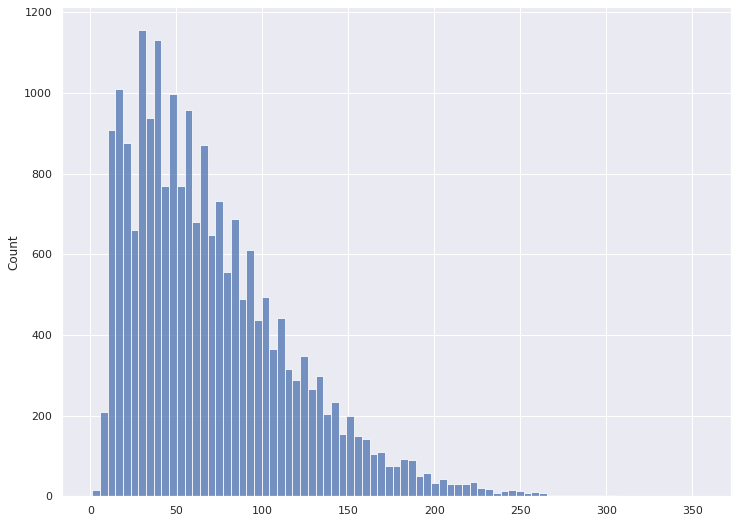

In [17]:
views_distr = rng.choice(a=views_distribution.views, size=N, replace=True, p=views_distribution.p) #создаём распределение на основе реальных данных
sns.histplot(views_distr)

<Axes: ylabel='Count'>

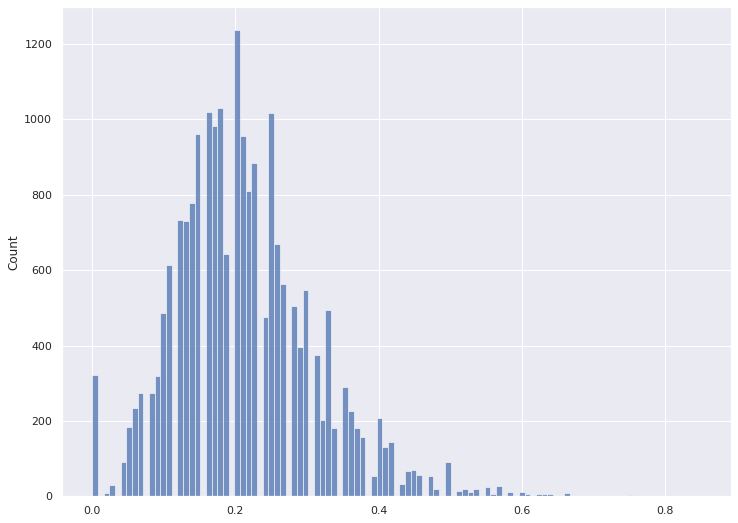

In [18]:
#сгенерируем и визуализируем распределение CTR
ctr_distribution['p'] = ctr_distribution['users']/ctr_distribution.users.sum()
ctr_distr = rng.choice(a=ctr_distribution.ctr, size=N, replace=True, p=ctr_distribution.p)
sns.histplot(ctr_distr)

Подсчитаем мощность для размера выборки = N. Для этого сэмплируем сэмплируем по 20998 наблюдений из сгенерированных данных,<br>
проведем тестирование t-тестом - сравним лайки t-тестом с поправкой Уэлча на неравные дисперсии (equal_var=False). Уровень значимости - 0.05, зафиксируем p-value в список. Повторим 20000 раз.

In [20]:
#количество симуляций 20000
#размер выборки N=20998
p_values=[] #список, куда будем сохранять значения p-values

for _ in tqdm(range(20000)):
    group_A_views = rng.choice(views_distribution['views'], size=N, replace=True, p=views_distribution['p']).astype("int32") #сэмплируем просмотры
    group_B_views = rng.choice(views_distribution['views'], size=N, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views = group_B_views + ((1 + rng.binomial(1, 0.5, N)) * rng.binomial(1, 0.9, N) * (group_B_views >= 50)) #добавляем новый эффект к просмотрам
     
    group_A_ctr = rng.choice(ctr_distribution['ctr'], size=N, replace=True, p=ctr_distribution['p']) #сэмплируем ctr
    group_B_ctr = rng.choice(ctr_distribution['ctr'], size=N, replace=True, p=ctr_distribution['p'])
    
    likes_A = rng.binomial(group_A_views, group_A_ctr) #реализуем лайки из биномиального распределения, как "успехи" при заданном количестве испытаний в зависимости от вероятности (ctr).
    likes_B = rng.binomial(group_B_views, group_B_ctr)
    
    p_values.append(stats.ttest_ind(likes_A, likes_B, equal_var=False).pvalue < 0.05) #сохраним True или False в список p-values
#подсчитаем мощность. Для этого просуммируем все элементы списка p-values (количество симуляций, где было обнаружено стат.значимое различие), разделим на общее количество симуляций*100. 
#в результате получим процент испытаний, где было обнаружно различие при наличии эффекта, значение 1-beta.
_1_minus_beta= (sum(p_values)/ 20000)*100
print(_1_minus_beta)

100%|██████████| 20000/20000 [04:38<00:00, 71.73it/s]

26.650000000000002


Мощность получилась 26.65%, это мало, меньше, чем желаемые 80%

### Задача 2
К нам снова пришли коллеги из ML-отдела с радостной новостью: они улучшили качество алгоритма! Теперь он срабатывает на пользователях с числом просмотров от 30 и выше.

In [23]:
#подкорректируем имитацию эффекта, снова запустим вычисление мощности
p_values=[]

for _ in tqdm(range(20000)):
    group_A_views = rng.choice(views_distribution['views'], size=N, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views = rng.choice(views_distribution['views'], size=N, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views2 = group_B_views + ((1 + rng.binomial(1, 0.5, N)) * rng.binomial(1, 0.9, N) * (group_B_views >= 30)) #новый эффект
    
    group_A_ctr = rng.choice(ctr_distribution['ctr'], size=N, replace=True, p=ctr_distribution['p'])
    group_B_ctr = rng.choice(ctr_distribution['ctr'], size=N, replace=True, p=ctr_distribution['p'])
    likes_A = rng.binomial(group_A_views, group_A_ctr)
    likes_B = rng.binomial(group_B_views2, group_B_ctr)
    p_values.append(stats.ttest_ind(likes_A, likes_B, equal_var=False).pvalue < 0.05)
_1_minus_beta= (sum(p_values)/ 20000)*100
print(_1_minus_beta)

100%|██████████| 20000/20000 [04:38<00:00, 71.69it/s]

41.955


Новое значение мощности 42.95%

### Задача 3
Теперь нас пришло радовать начальство: нам утвердили длительность эксперимента длиной в 2 недели! Давайте теперь допустим, что в эти две недели к нам придёт столько же пользователей, сколько пришло суммарно за период АА-теста и АБ-теста (опять же, смотрите диапазон дат в прошлом уроке).

Подкорректируйте размер группы соответствующим образом. Сами распределения, на основе которых мы симулируем данные, менять не будем.

даты АА теста '2026-02-20' - '2026-02-26'
даты АБ теста '2026-02-27' - '2026-03-05'

In [24]:
#выгрузим количество пользователей за эти 2 недели
users_2_weeks = """
SELECT COUNT(DISTINCT user_id)
FROM {db}.feed_actions
where toDate(time) between '2026-02-20' and '2026-03-05'
"""
n_users_2_weeks = pandahouse.read_clickhouse(users_2_weeks, connection=connection)
n_users_2_weeks

,COUNTDistinct(user_id)
0,61182


In [28]:
print(61182, ' - всего пользователей')
N_2_weeks=61182//2 #запишем размер выборки в переменную
print(N_2_weeks, ' - пользователей на группу')

61182  - всего пользователей
30591  - пользователей на группу


In [29]:
#снова рассчитаем мощность, но для нового количества пользователей в группах N_2_weeks = 30591
p_values=[]

for _ in tqdm(range(20000)):
    group_A_views = rng.choice(views_distribution['views'], size=N_2_weeks, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views = rng.choice(views_distribution['views'], size=N_2_weeks, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views2 = group_B_views + ((1 + rng.binomial(1, 0.5, N_2_weeks)) * rng.binomial(1, 0.9, N_2_weeks) * (group_B_views >= 30)) #новый эффект
    
    group_A_ctr = rng.choice(ctr_distribution['ctr'], size=N_2_weeks, replace=True, p=ctr_distribution['p'])
    group_B_ctr = rng.choice(ctr_distribution['ctr'], size=N_2_weeks, replace=True, p=ctr_distribution['p'])
    likes_A = rng.binomial(group_A_views, group_A_ctr)
    likes_B = rng.binomial(group_B_views2, group_B_ctr)
    p_values.append(stats.ttest_ind(likes_A, likes_B, equal_var=False).pvalue < 0.05)
_1_minus_beta= (sum(p_values)/ 20000)*100
print(_1_minus_beta)

100%|██████████| 20000/20000 [06:39<00:00, 50.06it/s]

56.220000000000006


Значение мощности 56.22%

### Задача 4
Всё это время мы анализировали наши выборки целиком — и тех пользователей, на которых алгоритм повлиял, и тех, кого он не мог затронуть (меньше 30 просмотров). А что, если мы будем отбирать только нужных пользователей и скармливать t-тесту именно их? Да, выборка будет меньше, но мы избавимся от мусора — а значит, и чувствительность наверняка будет выше. можем отсеять их примерно таким образом:

(здесь мы симулируем данные просмотров, CTR и лайков)

mask_A = group_A_views >= 30
mask_B = group_B_views >= 30

scipy.stats.ttest_ind(group_A_likes[mask_A], group_B_likes[mask_B], equal_var=False)

In [30]:
#рассчитаем новую мощность
N_2_weeks
p_values=[]

for _ in tqdm(range(20000)):
    group_A_views = rng.choice(views_distribution['views'], size=N_2_weeks, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views = rng.choice(views_distribution['views'], size=N_2_weeks, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views2 = group_B_views + ((1 + rng.binomial(1, 0.5, N_2_weeks)) * rng.binomial(1, 0.9, N_2_weeks) * (group_B_views >= 30)) #новый эффект
    
    group_A_ctr = rng.choice(ctr_distribution['ctr'], size=N_2_weeks, replace=True, p=ctr_distribution['p'])
    group_B_ctr = rng.choice(ctr_distribution['ctr'], size=N_2_weeks, replace=True, p=ctr_distribution['p'])
    likes_A = rng.binomial(group_A_views, group_A_ctr)
    likes_B = rng.binomial(group_B_views2, group_B_ctr)
    #маска для фильтрации пользователей
    mask_A = group_A_views >= 30
    mask_B = group_B_views >= 30
    p_values.append(stats.ttest_ind(likes_A[mask_A], likes_B[mask_B], equal_var=False).pvalue < 0.05) 
_1_minus_beta= (sum(p_values)/ 20000)*100
print(_1_minus_beta)

100%|██████████| 20000/20000 [06:43<00:00, 49.53it/s]

64.29


In [ ]:
Выводы: На коротком эксперименте мощность была недостаточной (41.56%).Увеличение периода эксперимента до двух недель дало прирост (56.36%).
Фильтрация нерелевантных пользователей (по просмотрам) привела к улучшению чувствительности (64.07%)

Симуляции позволяют оценить реалистичность фиксации эффекта до запуска теста



Низкая мощность при 1 и 2 неделях означает, что при текущем размере трафика и ожидаемом эффекте тест не сможет статистически надёжно зафиксировать увеличение просмотров новостей, даже если эффект существует.

Ключевые выводы
Параметр	Вывод
Параметр	Вывод
Длительность теста	Увеличение с 1 до 2 недель не решило проблему → количество пользователей за 2 недели недостаточно для обнаружения эффекта 
Размер эффекта	Ожидаемый прирост просмотров, вероятно, слишком мал (MDE слишком оптимистичен) → чем меньше эффект, тем больше выборка нужна 
Трафик	Текущий объём трафика не позволяет достичь мощности 80% даже за 2 недели 
Методология	Монте-Карло — корректный подход для сложных метрик, результат симуляции надёжен 
Что делать дальше
Увеличить размер трафика — если есть возможность, запустить тест на большем сегменте пользователей (например, 50% вместо 10%).

Пересчитать с большим MDE — если эффект в 5% нереалистичен, рассчитать мощность для большего эффекта (10–15%), который бизнес считает ценным.

Увеличить длительность — попробовать 3–4 недели, если сезонность позволяет и нет риска contamination.

Изменить метрику — найти более чувствительную метрику (например, время просмотра вместо просмотров, или конверсию в клики), которая покажет больший эффект.

CUPED или стратификация — применить variance reduction техники для повышения мощности без увеличения выборки.

Принять решение — если трафик и время ограничены, возможно, тест невозможно провести надёжно → рассматривать эффект как гипотезу для будущего исследования.

Резюме: тест с текущими параметрами не имеет достаточной статистической мощности. Нужно либо увеличить трафик/время, либоExpect более крупный эффект, либо изменить метрику.

In [ ]:
#рассчитаем новую мощность
N_3_weeks= N_2_weeks//2*3
p_values=[]

for _ in tqdm(range(2000)):
    group_A_views = rng.choice(views_distribution['views'], size=N_3_weeks, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views = rng.choice(views_distribution['views'], size=N_3_weeks, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views2 = group_B_views + ((1 + rng.binomial(1, 0.5, N_3_weeks)) * rng.binomial(1, 0.9, N_3_weeks) * (group_B_views >= 30)) #новый эффект
    
    group_A_ctr = rng.choice(ctr_distribution['ctr'], size=N_3_weeks, replace=True, p=ctr_distribution['p'])
    group_B_ctr = rng.choice(ctr_distribution['ctr'], size=N_3_weeks, replace=True, p=ctr_distribution['p'])
    likes_A = rng.binomial(group_A_views, group_A_ctr)
    likes_B = rng.binomial(group_B_views2, group_B_ctr)
    #маска для фильтрации пользователей
    mask_A = group_A_views >= 30
    mask_B = group_B_views >= 30
    p_values.append(stats.ttest_ind(likes_A[mask_A], likes_B[mask_B], equal_var=False).pvalue < 0.05) 
_1_minus_beta= (sum(p_values)/ 20000)*100
print(_1_minus_beta)